認識s=25, 50, 75に関して、それぞれA, qsの精度をパラメータとしてpBS,pKLDを三次元プロット.
ここでAの「精度」（sa1は逆）をs<=50で低く、s>=51で高く設定

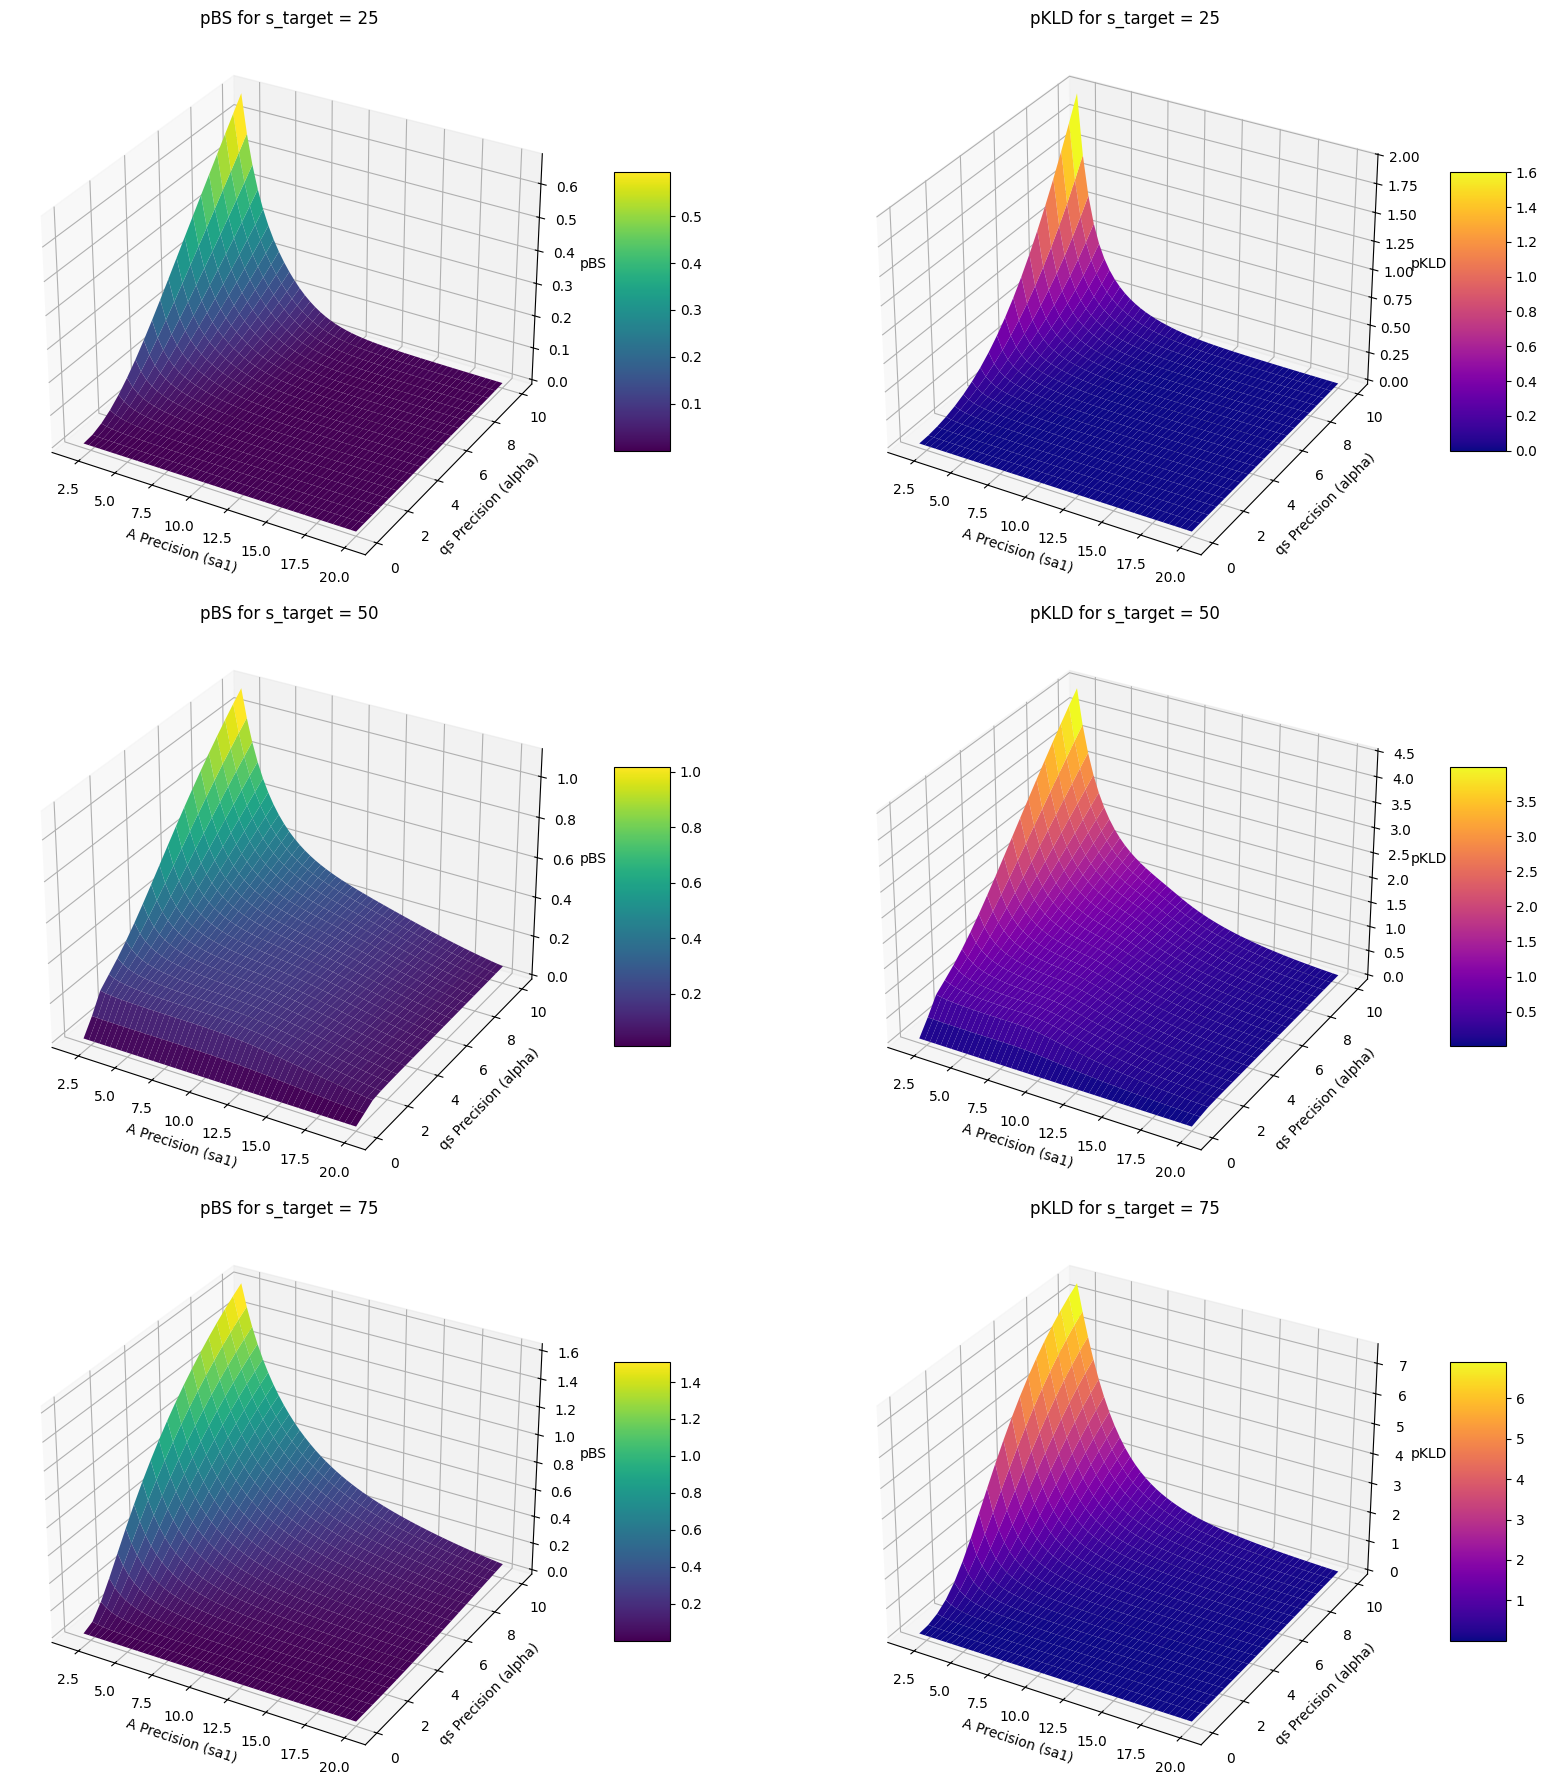

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import norm

# pymdp.utils の機能を再現するためのダミー関数
def plot_likelihood(A, title, origin='upper'):
    plt.figure(figsize=(12, 12))
    plt.imshow(A, cmap='viridis', origin=origin)
    plt.colorbar(label='Probability')
    plt.xlabel('States (s)')
    plt.ylabel('Observations (o)')
    plt.title(title)
    plt.tight_layout()
    plt.show()

def obj_array_zeros(shapes):
    if isinstance(shapes[0], list):
        o_dim = shapes[0][0]
        s_dim = shapes[1][0] if isinstance(shapes[1], list) else shapes[1]
    else:
        o_dim = shapes[0]
        s_dim = shapes[1]
    return np.zeros((o_dim, s_dim), dtype=float)

def wrapped_norm_pdf(x, mean, std, wrap_size):
    pdf = np.zeros_like(x, dtype=np.float64)
    for k in [-1, 0, 1]:
        pdf += (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean + k * wrap_size) / std) ** 2)
    return pdf

def generate_qs2(alpha, dim):
    qs = norm.pdf(np.arange(dim), loc=(dim-1)/2, scale=alpha)
    qs = qs / (qs.sum() + epsilon)
    return qs

# モデル設定
s_dim = 100
o_dim = 100
epsilon = 1e-8

l = np.arange(0, 100, 1)
obs_range_size = 100
A_shapes = [o_dim, s_dim]

# さまざまなsa1（Aの精度）の値を設定
#sa1_values = np.array([2.0, 5.0, 10.0, 20.0])
#sa1_values = np.linspace(2.0, 20.0, 50)
sa1_values = np.linspace(epsilon, 10, 20)

# qsの精度(alpha)の範囲
alphas = np.linspace(epsilon, 10, 20)

# シミュレーションを行う目標状態
target_states = [25, 50, 75]

# 結果を格納する辞書
results_pBS = {}
results_pKLD = {}

# メッシュグリッドの作成 (ループの外で一度だけ作成)
# Xがsa1、Yがalphaとなるように定義
X_sa1, Y_alpha = np.meshgrid(sa1_values, alphas)

for s_target in target_states:
    # 各s_targetごとにpBSとpKLDの2D配列を初期化
    # shape: (len(alphas), len(sa1_values)) - meshgridの形状に合わせる
    pBS_matrix = np.zeros((len(alphas), len(sa1_values)))
    pKLD_matrix = np.zeros((len(alphas), len(sa1_values)))
    
    for i, sa1_val in enumerate(sa1_values): # sa1_val はX軸に対応 (列方向のインデックス)
        # A_array (尤度行列 p(o|s)) の定義
        A_array = obj_array_zeros(A_shapes)
        for s_idx in range(s_dim):
            current_sa = sa1_val * 3.0 if s_idx < 51 else sa1_val * 1.0
            A_array[:, s_idx] = wrapped_norm_pdf(l, s_idx, current_sa, obs_range_size) + epsilon
        A_array /= (A_array.sum(axis=0, keepdims=True) + epsilon)

        log_A_array = np.log(A_array + epsilon)

        for j, alpha_val in enumerate(alphas): # alpha_val はY軸に対応 (行方向のインデックス)
            # qs (隠れ状態に関する信念) の定義
            # qsのmeanをs_targetに設定
            qs = wrapped_norm_pdf(np.arange(s_dim), s_target, alpha_val, s_dim)
            qs /= (qs.sum() + epsilon)

            # 予測観測 qo の計算
            qo = A_array @ qs
            qo /= (qo.sum() + epsilon)

            # entropy_qo (予測エントロピー) の計算
            entropy_qo = -np.sum(qo * np.log(qo + epsilon))

            # Ambiguity (A行列の重み付けされたエントロピー) の計算
            H_A_per_s = -np.sum(A_array * np.log(A_array + epsilon), axis=0)
            weighted_A_entropy = np.sum(H_A_per_s * qs) # Ambiguity
            
            # pBS の計算
            pBS = entropy_qo - weighted_A_entropy
            
            # cross_entropy の計算 (修正済み)
            expected_log_p_o_given_s = (qs[None, :] * log_A_array).sum(axis=1)
            cross_entropy = -np.sum(qo * expected_log_p_o_given_s)
            
            # pKLD の計算
            pKLD = cross_entropy - entropy_qo
            
            # 結果を格納
            pBS_matrix[j, i] = pBS
            pKLD_matrix[j, i] = pKLD

    results_pBS[s_target] = pBS_matrix
    results_pKLD[s_target] = pKLD_matrix

# --- 3Dプロットの描画 ---
fig = plt.figure(figsize=(18, 18)) # 全体の図のサイズを調整 (3x2サブプロット用)

for idx, s_target in enumerate(target_states):
    # pBS のプロット
    ax1 = fig.add_subplot(len(target_states), 2, idx * 2 + 1, projection='3d')
    surf1 = ax1.plot_surface(X_sa1, Y_alpha, results_pBS[s_target], cmap='viridis')
    ax1.set_title(f'pBS for s_target = {s_target}')
    ax1.set_xlabel('A Precision (sa1)')
    ax1.set_ylabel('qs Precision (alpha)')
    ax1.set_zlabel('pBS')
    fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=5)

    # pKLD のプロット
    ax2 = fig.add_subplot(len(target_states), 2, idx * 2 + 2, projection='3d')
    surf2 = ax2.plot_surface(X_sa1, Y_alpha, results_pKLD[s_target], cmap='plasma')
    ax2.set_title(f'pKLD for s_target = {s_target}')
    ax2.set_xlabel('A Precision (sa1)')
    ax2.set_ylabel('qs Precision (alpha)')
    ax2.set_zlabel('pKLD')
    fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=5)

plt.tight_layout()
plt.show()

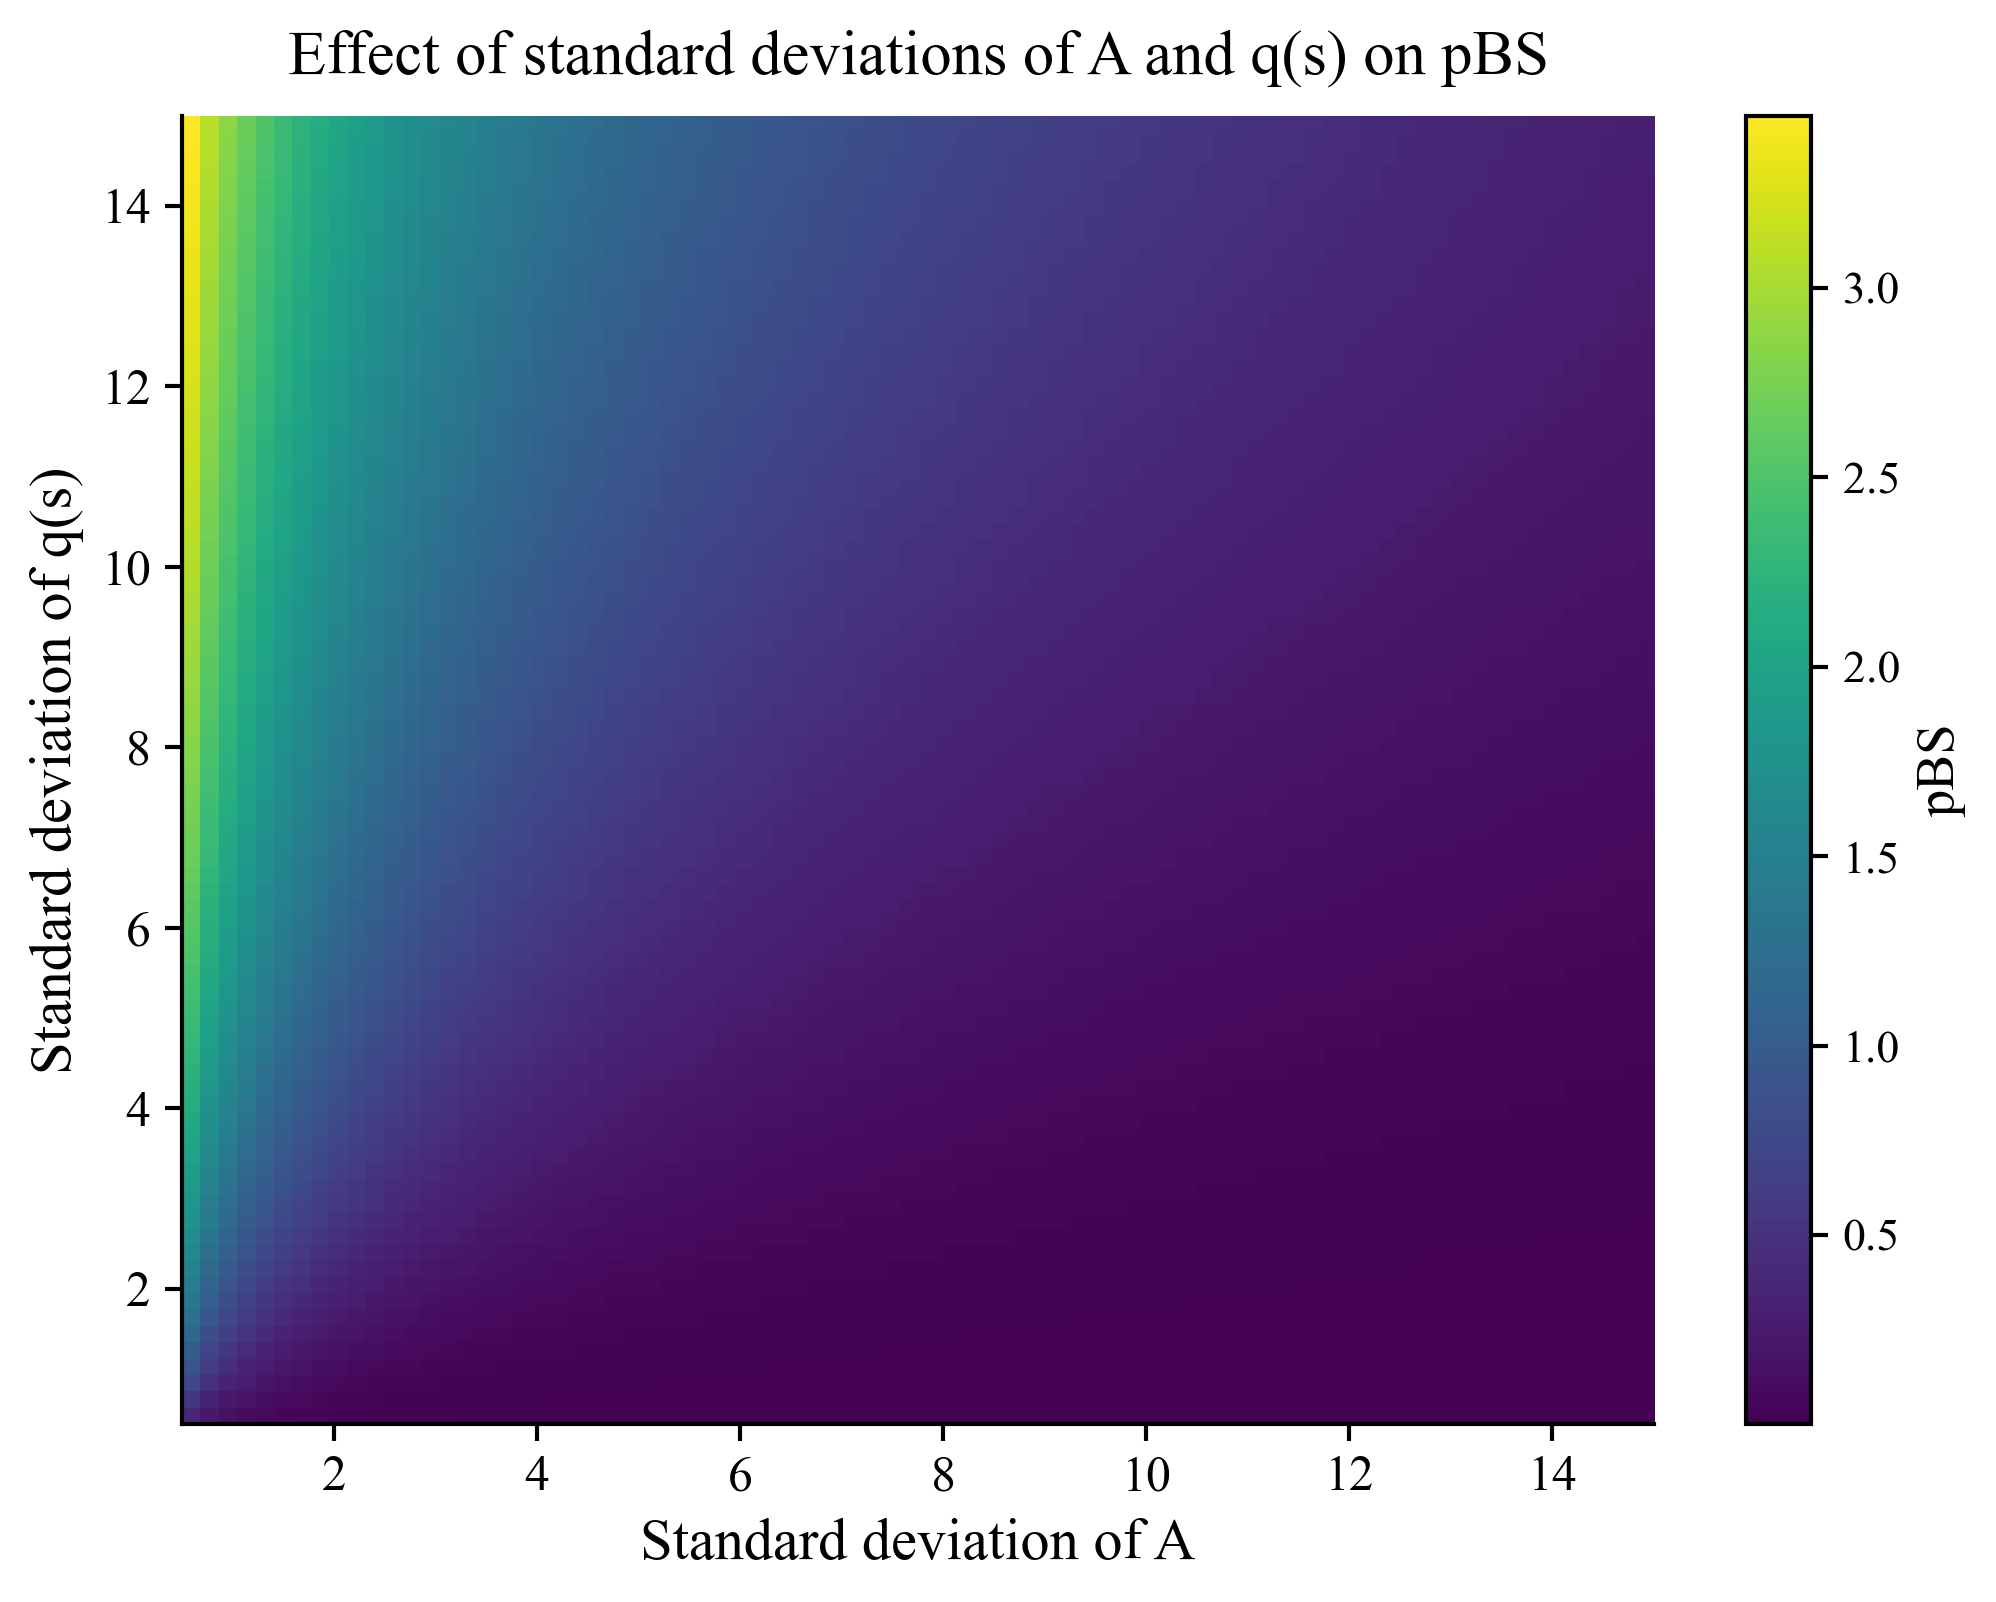

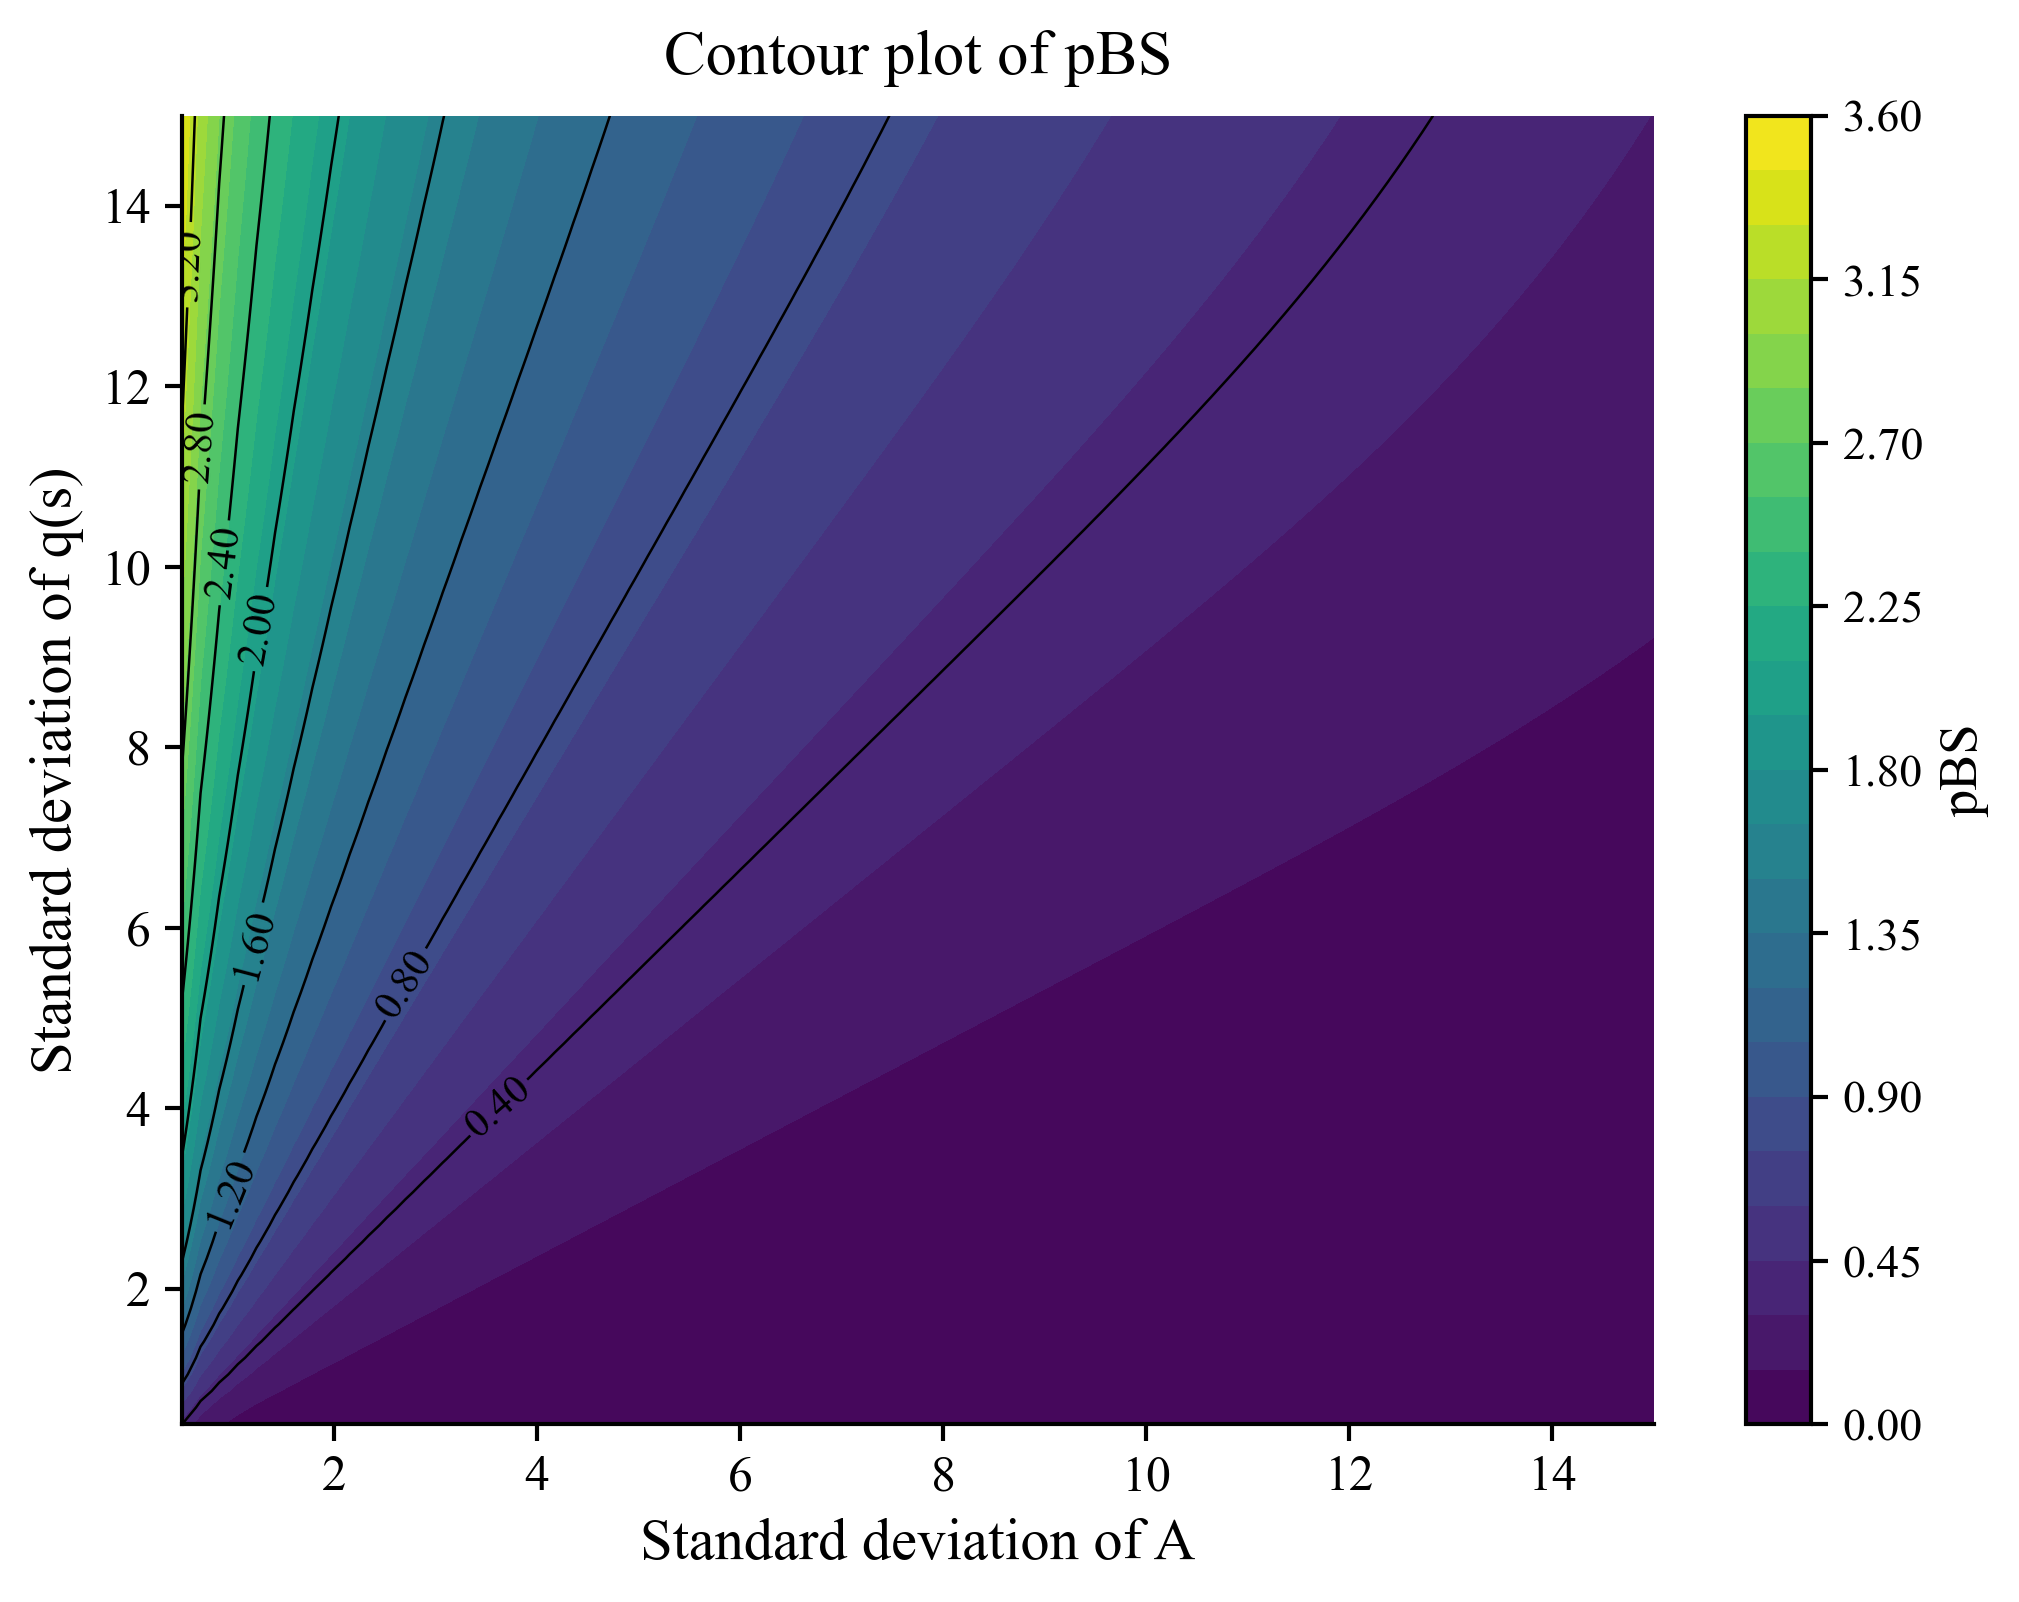

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# =========================
# 1. 表示スタイル設定（APA風）
# =========================
FONT_FAMILY = "Times New Roman"

LABEL_SIZE = 14      # 軸ラベル
TICK_SIZE = 12       # 目盛り
TITLE_SIZE = 15      # タイトル
CBAR_LABEL_SIZE = 13 # カラーバーラベル
CBAR_TICK_SIZE = 11  # カラーバー目盛り

FIG_WIDTH = 7.0
FIG_HEIGHT = 5.5
DPI = 300

AXIS_LINEWIDTH = 1.0
TICK_WIDTH = 1.0
TICK_LENGTH = 4

rcParams["font.family"] = FONT_FAMILY
rcParams["font.size"] = 12
rcParams["axes.linewidth"] = AXIS_LINEWIDTH
rcParams["xtick.major.width"] = TICK_WIDTH
rcParams["ytick.major.width"] = TICK_WIDTH
rcParams["xtick.major.size"] = TICK_LENGTH
rcParams["ytick.major.size"] = TICK_LENGTH
rcParams["pdf.fonttype"] = 42
rcParams["ps.fonttype"] = 42

# =========================
# 2. 補助関数
# =========================
epsilon = 1e-12

def wrapped_norm_pdf(x, mean, std, wrap_size):
    """
    周期境界つき正規分布
    """
    pdf = np.zeros_like(x, dtype=np.float64)
    for k in [-1, 0, 1]:
        pdf += np.exp(-0.5 * ((x - mean + k * wrap_size) / std) ** 2) / (std * np.sqrt(2 * np.pi))
    return pdf

def compute_pbs(A, qs, eps=1e-12):
    """
    pBS = H[q(o)] - E_q(s)[ H[p(o|s)] ]
    """
    qo = A @ qs
    qo = qo / (qo.sum() + eps)

    entropy_qo = -np.sum(qo * np.log(qo + eps))
    H_A_per_s = -np.sum(A * np.log(A + eps), axis=0)
    ambiguity = np.sum(H_A_per_s * qs)

    pbs = entropy_qo - ambiguity
    return pbs

def make_likelihood_matrix(s_dim, o_dim, A_std, eps=1e-12):
    """
    A(o|s) を作る
    各状態 s に対して、観測分布は mean=s の wrapped Gaussian
    """
    obs = np.arange(o_dim)
    A = np.zeros((o_dim, s_dim), dtype=np.float64)

    for s in range(s_dim):
        A[:, s] = wrapped_norm_pdf(obs, mean=s, std=A_std, wrap_size=o_dim) + eps

    A /= (A.sum(axis=0, keepdims=True) + eps)
    return A

def make_qs(s_dim, mean, qs_std, eps=1e-12):
    """
    q(s) を作る
    平均は固定（ここでは 50.5）
    """
    states = np.arange(s_dim)
    qs = wrapped_norm_pdf(states, mean=mean, std=qs_std, wrap_size=s_dim) + eps
    qs /= (qs.sum() + eps)
    return qs

# =========================
# 3. モデル設定
# =========================
s_dim = 100
o_dim = 100
qs_mean = 50.5  # 指定どおりベクトル中心値

# 標準偏差の範囲
qs_std_values = np.linspace(0.5, 15.0, 80)
A_std_values = np.linspace(0.5, 15.0, 80)

# 結果格納
pbs_matrix = np.zeros((len(qs_std_values), len(A_std_values)))

# =========================
# 4. pBS計算
# =========================
for i, qs_std in enumerate(qs_std_values):
    qs = make_qs(s_dim=s_dim, mean=qs_mean, qs_std=qs_std, eps=epsilon)

    for j, A_std in enumerate(A_std_values):
        A = make_likelihood_matrix(s_dim=s_dim, o_dim=o_dim, A_std=A_std, eps=epsilon)
        pbs_matrix[i, j] = compute_pbs(A, qs, eps=epsilon)

# =========================
# 5. プロット1：ヒートマップ
# =========================
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT), dpi=DPI)

im = ax.imshow(
    pbs_matrix,
    origin="lower",
    aspect="auto",
    extent=[A_std_values.min(), A_std_values.max(),
            qs_std_values.min(), qs_std_values.max()],
    cmap="viridis"
)

# 軸ラベル
ax.set_xlabel("Standard deviation of A", fontsize=LABEL_SIZE)
ax.set_ylabel("Standard deviation of q(s)", fontsize=LABEL_SIZE)

# タイトル（不要ならコメントアウト）
ax.set_title("Effect of standard deviations of A and q(s) on pBS", fontsize=TITLE_SIZE, pad=10)

# 目盛りサイズ
ax.tick_params(axis="both", labelsize=TICK_SIZE)

# 上右枠を消す（APAでよく使う簡潔な見た目）
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# カラーバー
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("pBS", fontsize=CBAR_LABEL_SIZE)
cbar.ax.tick_params(labelsize=CBAR_TICK_SIZE)

plt.tight_layout()
plt.show()

# =========================
# 6. プロット2：等高線つきヒートマップ
# =========================
X, Y = np.meshgrid(A_std_values, qs_std_values)

fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT), dpi=DPI)

cf = ax.contourf(X, Y, pbs_matrix, levels=30, cmap="viridis")
cs = ax.contour(X, Y, pbs_matrix, levels=10, colors="black", linewidths=0.6)

ax.clabel(cs, inline=True, fontsize=10, fmt="%.2f")

ax.set_xlabel("Standard deviation of A", fontsize=LABEL_SIZE)
ax.set_ylabel("Standard deviation of q(s)", fontsize=LABEL_SIZE)
ax.set_title("Contour plot of pBS", fontsize=TITLE_SIZE, pad=10)
ax.tick_params(axis="both", labelsize=TICK_SIZE)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

cbar = plt.colorbar(cf, ax=ax)
cbar.set_label("I(s;o|π)", fontsize=CBAR_LABEL_SIZE)
cbar.ax.tick_params(labelsize=CBAR_TICK_SIZE)

plt.tight_layout()
plt.show()

/tmp/ipykernel_54274/3996037379.py:176: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()#pad=1.5


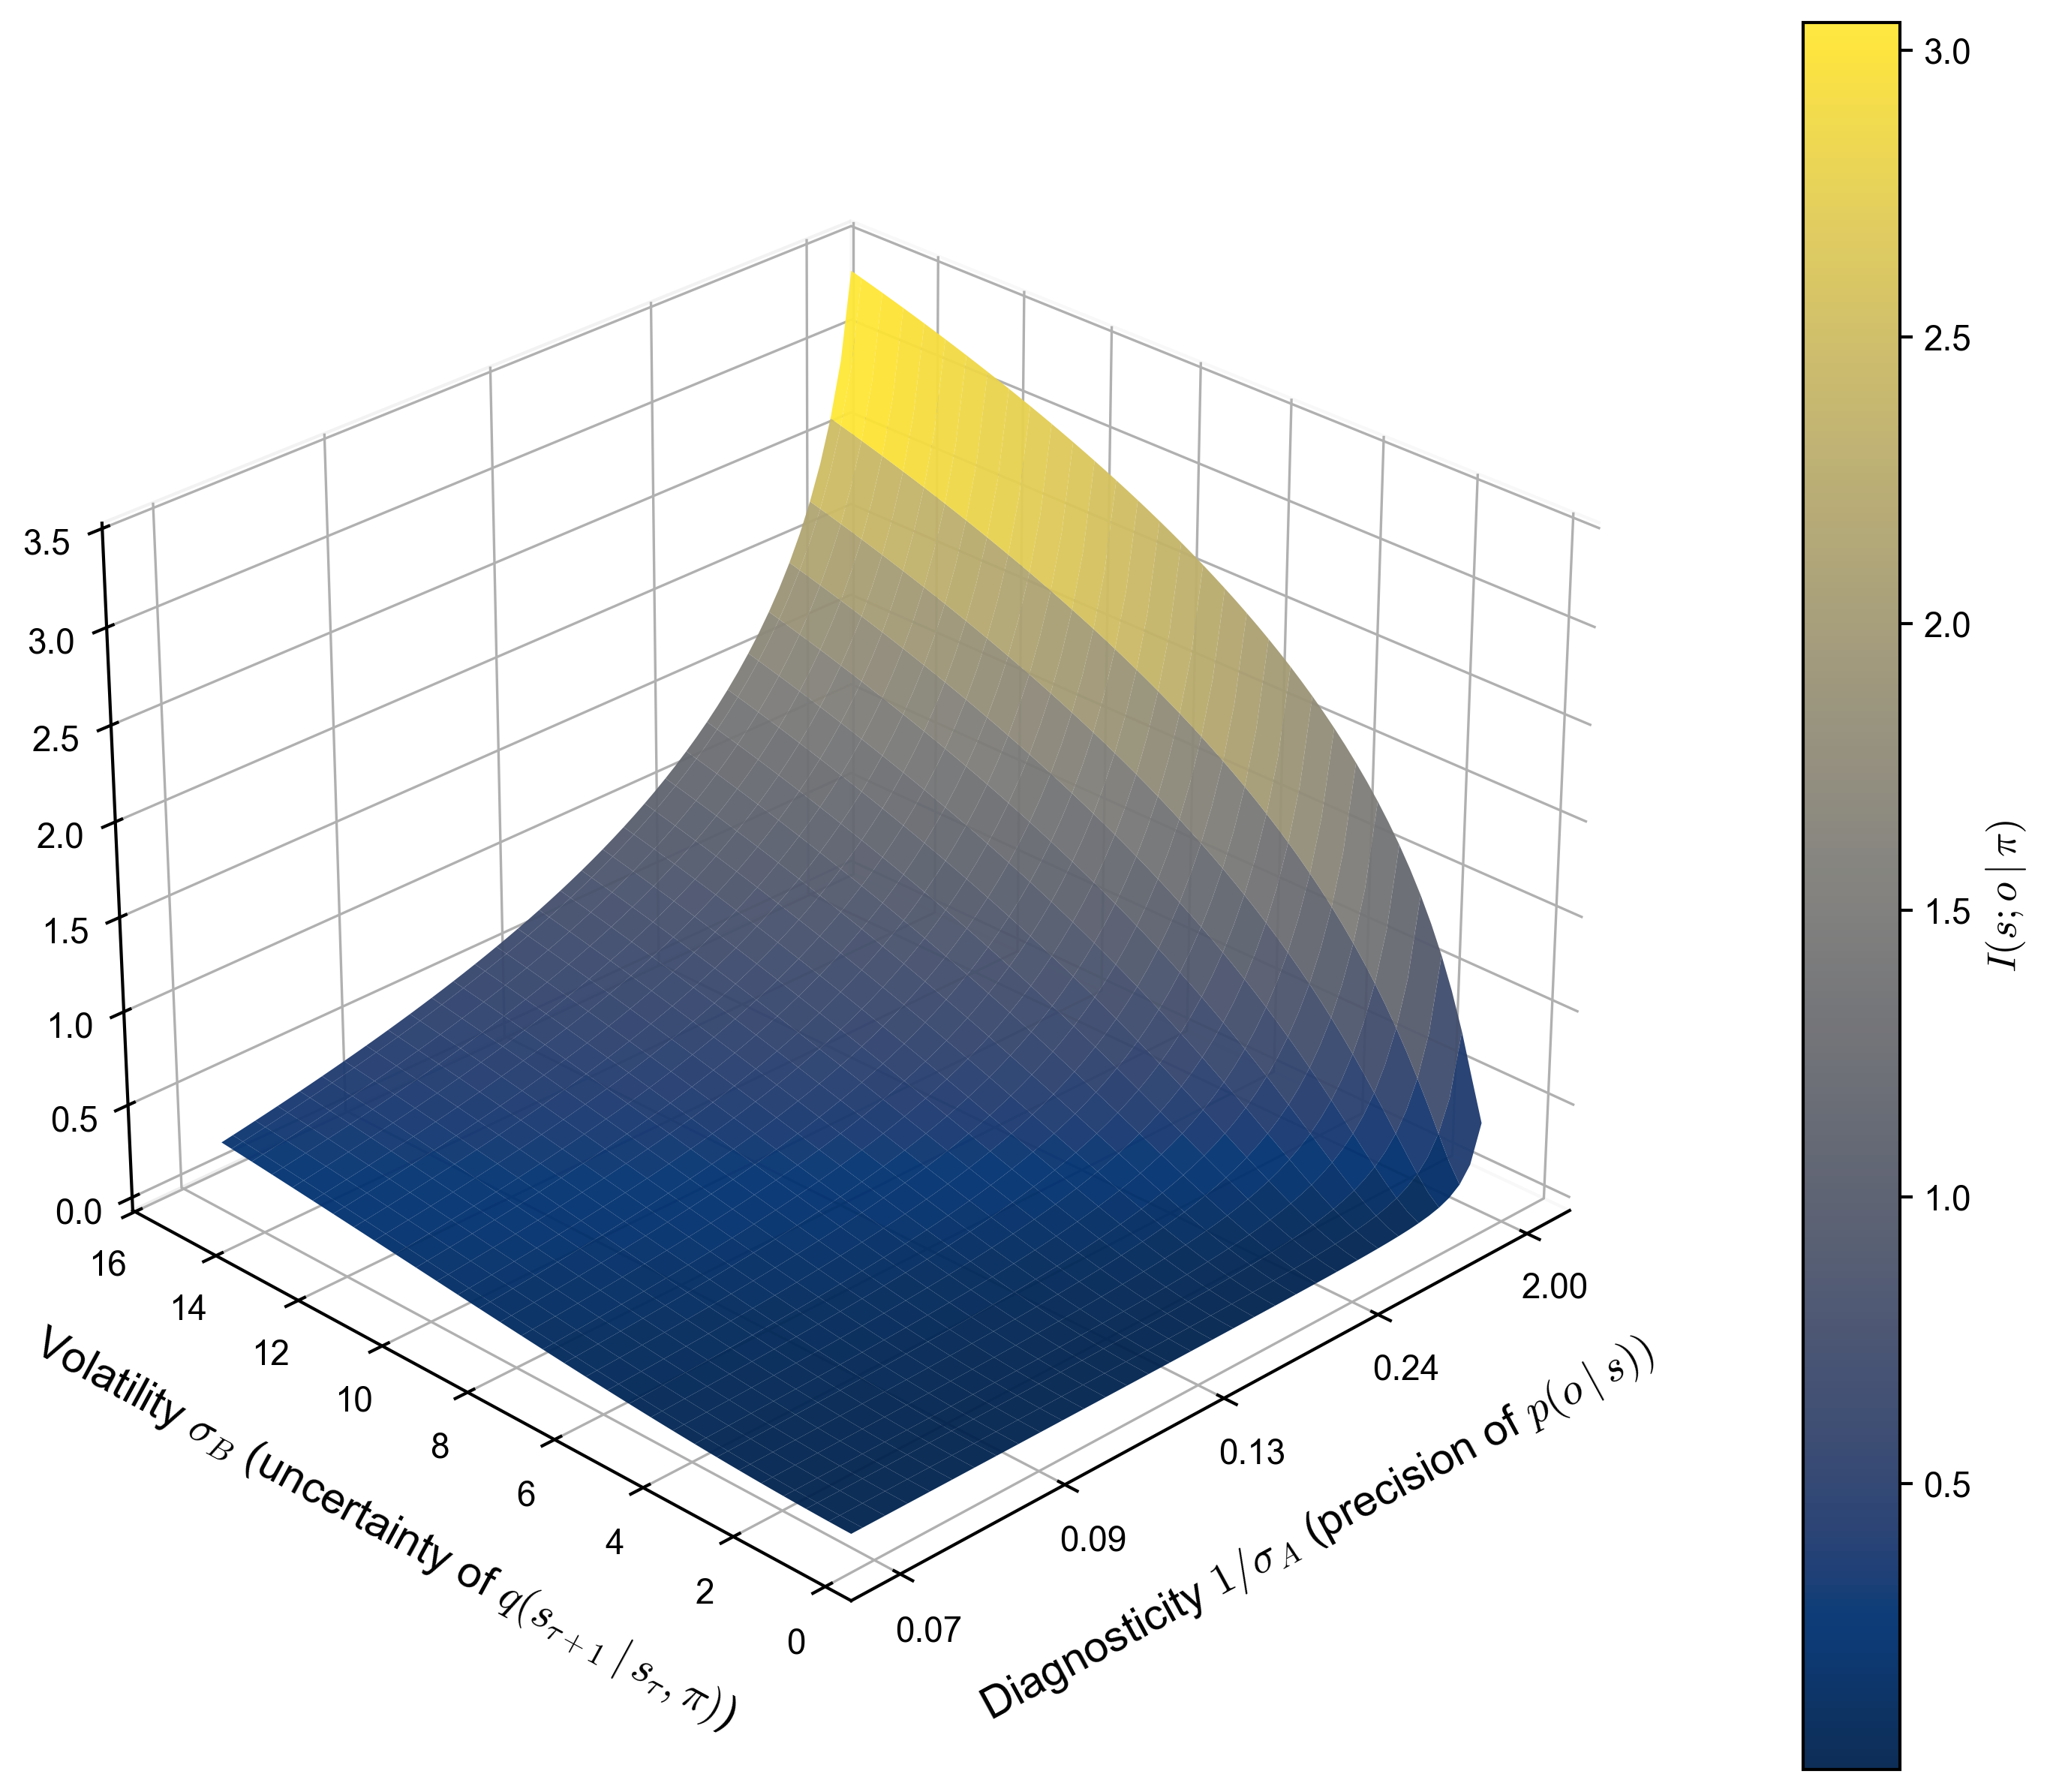

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ==================================
# 1. 表示スタイル設定（APA風 + 調整しやすい）
# ==================================
FONT_FAMILY = "Arial"#"Times New Roman"

LABEL_SIZE = 14
TICK_SIZE = 11
TITLE_SIZE = 15
CBAR_LABEL_SIZE = 13
CBAR_TICK_SIZE = 11

FIG_WIDTH = 12#7.5
FIG_HEIGHT = 14#6.0#6.0
DPI = 300

AXIS_LINEWIDTH = 1.0
TICK_WIDTH = 1.0
TICK_LENGTH = 4

SURFACE_ALPHA = 0.95
VIEW_ELEV = 28
VIEW_AZIM = -135

# 色覚多様性に配慮したカラーマップ
CMAP = "cividis"

rcParams["font.family"] = FONT_FAMILY
rcParams["font.size"] = 12
rcParams["axes.linewidth"] = AXIS_LINEWIDTH
rcParams["xtick.major.width"] = TICK_WIDTH
rcParams["ytick.major.width"] = TICK_WIDTH
rcParams["xtick.major.size"] = TICK_LENGTH
rcParams["ytick.major.size"] = TICK_LENGTH
rcParams["pdf.fonttype"] = 42
rcParams["ps.fonttype"] = 42

rcParams["mathtext.fontset"] = "cm"

# ==================================
# 2. パラメータ
# ==================================
epsilon = 1e-12
s_dim = 100
o_dim = 100
qs_mean = 50.5  # ベクトル中心

# 標準偏差の範囲
qs_std_values = np.linspace(0.5, 15.0, 60)
A_std_values = np.linspace(0.5, 15.0, 60)

# ==================================
# 3. 補助関数
# ==================================
def wrapped_norm_pdf(x, mean, std, wrap_size):
    """
    周期境界つき正規分布
    """
    pdf = np.zeros_like(x, dtype=np.float64)
    for k in [-1, 0, 1]:
        pdf += np.exp(-0.5 * ((x - mean + k * wrap_size) / std) ** 2) / (std * np.sqrt(2 * np.pi))
    return pdf

def make_likelihood_matrix(s_dim, o_dim, A_std, eps=1e-12):
    """
    A(o|s) を作る
    各状態 s に対して mean=s の wrapped Gaussian を観測分布とする
    """
    obs = np.arange(o_dim)
    A = np.zeros((o_dim, s_dim), dtype=np.float64)

    for s in range(s_dim):
        A[:, s] = wrapped_norm_pdf(obs, mean=s, std=A_std, wrap_size=o_dim) + eps

    A /= (A.sum(axis=0, keepdims=True) + eps)
    return A

def make_qs(s_dim, mean, qs_std, eps=1e-12):
    """
    q(s) を作る
    """
    states = np.arange(s_dim)
    qs = wrapped_norm_pdf(states, mean=mean, std=qs_std, wrap_size=s_dim) + eps
    qs /= (qs.sum() + eps)
    return qs

def compute_pbs(A, qs, eps=1e-12):
    """
    pBS = H[q(o)] - E_q(s)[ H[p(o|s)] ]
    """
    qo = A @ qs
    qo /= (qo.sum() + eps)

    entropy_qo = -np.sum(qo * np.log(qo + eps))
    H_A_per_s = -np.sum(A * np.log(A + eps), axis=0)
    ambiguity = np.sum(H_A_per_s * qs)

    pbs = entropy_qo - ambiguity
    return pbs

# ==================================
# 4. pBS の計算
# ==================================
pbs_matrix = np.zeros((len(qs_std_values), len(A_std_values)))

for i, qs_std in enumerate(qs_std_values):
    qs = make_qs(s_dim=s_dim, mean=qs_mean, qs_std=qs_std, eps=epsilon)

    for j, A_std in enumerate(A_std_values):
        A = make_likelihood_matrix(s_dim=s_dim, o_dim=o_dim, A_std=A_std, eps=epsilon)
        pbs_matrix[i, j] = compute_pbs(A, qs, eps=epsilon)

# メッシュグリッド
X_A_std, Y_qs_std = np.meshgrid(A_std_values, qs_std_values)

# ==================================
# 5. 3D surface plot
# ==================================
fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT), dpi=DPI)
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    X_A_std,
    Y_qs_std,
    pbs_matrix,
    cmap=CMAP,
    linewidth=0,
    antialiased=True,
    alpha=SURFACE_ALPHA
)
ax.invert_xaxis()
# x軸の目盛り位置（元の sa の値）
xticks = np.linspace(A_std_values.min(), A_std_values.max(), 5)
# 表示ラベルを 1/sa に変換
xtick_labels = [f"{1/x:.2f}" for x in xticks]
ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels)
# 軸ラベル
# ax.set_xlabel(r"Standard deviation of $p(o\mid s)$", fontsize=LABEL_SIZE, labelpad=12)
# ax.set_ylabel(r"Standard deviation of $q(s\mid \pi)$", fontsize=LABEL_SIZE, labelpad=12)
ax.set_xlabel(r"Diagnosticity $1/\sigma_{A}$ (precision of $p(o\mid s))$", fontsize=LABEL_SIZE, labelpad=12)
#ax.set_ylabel(r"Volatility $\sigma_{B}$ (uncertainty of $q(s\mid \pi)$)", fontsize=LABEL_SIZE, labelpad=12)
ax.set_ylabel(r"Volatility $\sigma_{B}$ (uncertainty of $q(s_{\tau + 1}\mid s_{\tau}, \pi)$)", fontsize=LABEL_SIZE, labelpad=12)
ax.set_zlabel(r"$I(s;o\mid \pi)$", fontsize=LABEL_SIZE, labelpad=10)

# タイトル（不要ならコメントアウト可）
#ax.set_title(r"Effect of standard deviations of A and q(s) on pBS", fontsize=TITLE_SIZE, pad=14)

# 目盛り
ax.tick_params(axis="x", labelsize=TICK_SIZE, pad=2)
ax.tick_params(axis="y", labelsize=TICK_SIZE, pad=2)
ax.tick_params(axis="z", labelsize=TICK_SIZE, pad=2)

# 視点
ax.view_init(elev=VIEW_ELEV, azim=VIEW_AZIM)

# 背景面をすっきりさせる
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

# グリッドを薄く表示
ax.grid(True)

# カラーバー
cbar = fig.colorbar(surf, ax=ax, shrink=0.72, aspect=18, pad=0.08)
cbar.set_label(r"$I(s;o\mid \pi)$", fontsize=CBAR_LABEL_SIZE)
cbar.ax.tick_params(labelsize=CBAR_TICK_SIZE)



plt.tight_layout()#pad=1.5
plt.show()

# ==================================
# 6. 保存したい場合
# ==================================
fig.savefig("pBS_3D_surface_cividis.pdf", bbox_inches="tight")
fig.savefig("pBS_3D_surface_cividis.png", bbox_inches="tight", dpi=600)